In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix


In [2]:
# =====================================================
# LOAD DATA
# =====================================================

pred_df = df = pd.read_csv("/projects/e32998/STAT390_Winter2026/Team1/Code/MIL_trainer_9Dec_JointFinal/run_1/predictions.csv")


Extracted:
Train losses: 11
Val losses: 11
Val accs: 11
LR values: 11


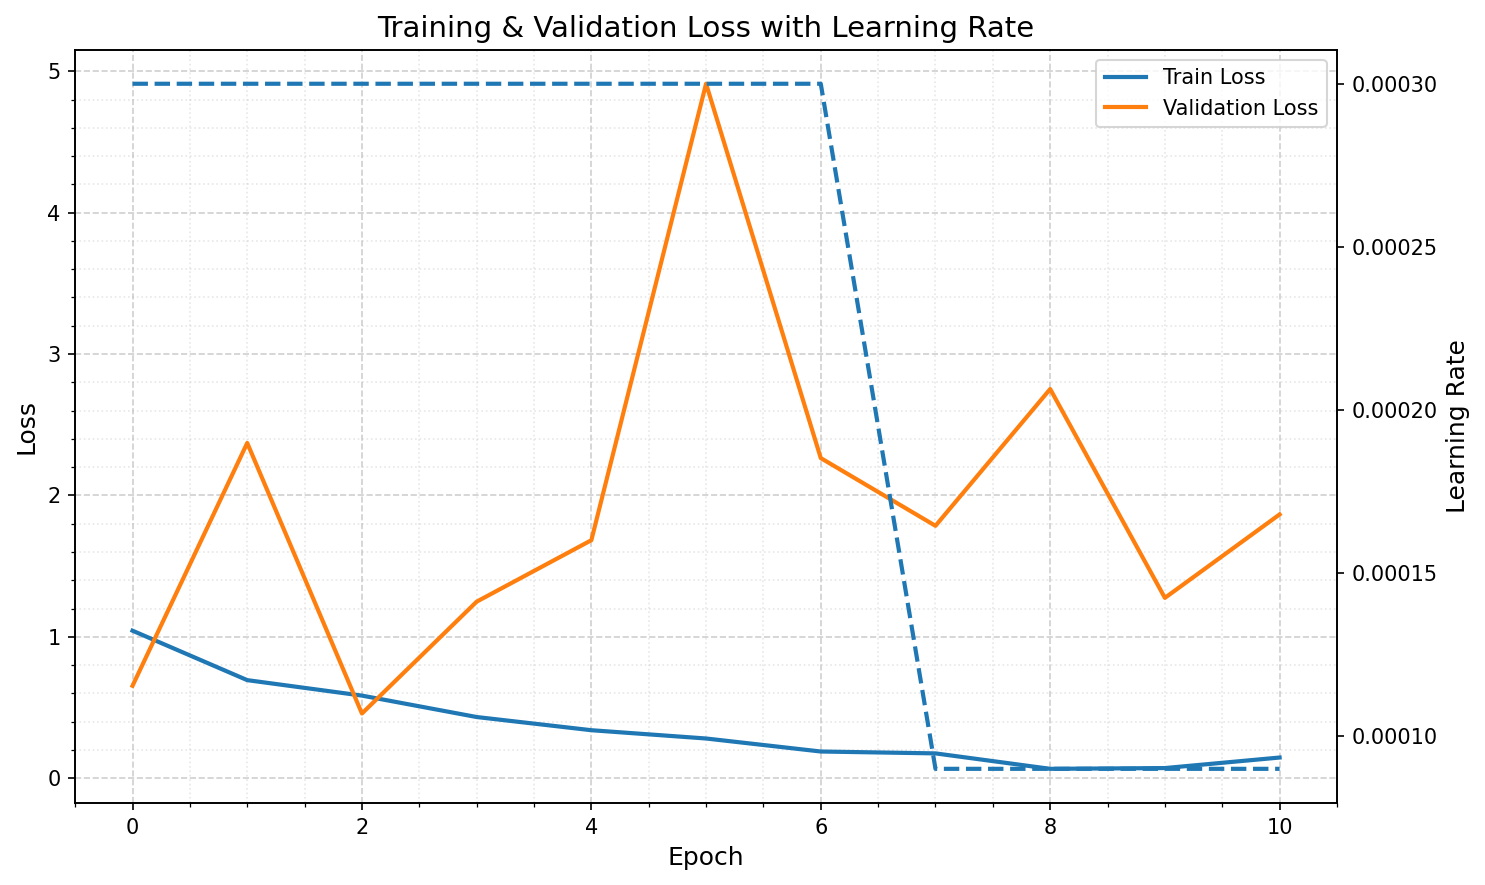

In [8]:
import re
import matplotlib.pyplot as plt

# =====================================================
# EXTRACT METRICS + PLOT (ALL-IN-ONE)
# =====================================================

def extract_and_plot(log_path):

    train_losses, val_losses, val_accs, lrs = [], [], [], []
    current_lr = None

    # Robust patterns
    loss_pattern = re.compile(
        r"Train Loss:\s*([0-9eE\.\-]+).*Val Loss:\s*([0-9eE\.\-]+).*Val Acc:\s*([0-9eE\.\-]+)"
    )
    lr_pattern = re.compile(r"LR:\s*([0-9eE\.\-]+)")

    with open(log_path, "r") as f:
        for line in f:

            lr_match = lr_pattern.search(line)
            if lr_match:
                current_lr = float(lr_match.group(1))

            loss_match = loss_pattern.search(line)
            if loss_match:
                train_losses.append(float(loss_match.group(1)))
                val_losses.append(float(loss_match.group(2)))
                val_accs.append(float(loss_match.group(3)))
                lrs.append(current_lr)

    print("Extracted:")
    print("Train losses:", len(train_losses))
    print("Val losses:", len(val_losses))
    print("Val accs:", len(val_accs))
    print("LR values:", len(lrs))

    if len(train_losses) == 0:
        print("\n⚠️ No data extracted. Check log formatting.")
        return

    # ==========================
    # PLOT
    # ==========================
    fig, ax1 = plt.subplots(figsize=(10,6), dpi=150)

    # Loss curves
    ax1.plot(train_losses, label="Train Loss", linewidth=2)
    ax1.plot(val_losses, label="Validation Loss", linewidth=2)

    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)
    ax1.legend(loc="upper right")

    # Grid styling
    ax1.grid(True, which="major", linestyle="--", alpha=0.6)
    ax1.minorticks_on()
    ax1.grid(True, which="minor", linestyle=":", alpha=0.3)

    # Learning rate axis
    ax2 = ax1.twinx()
    ax2.plot(lrs, linestyle="--", linewidth=2)
    ax2.set_ylabel("Learning Rate", fontsize=12)

    plt.title("Training & Validation Loss with Learning Rate", fontsize=14)
    plt.tight_layout()
    plt.show()


# =====================================================
# RUN
# =====================================================

log_path = "/projects/e32998/STAT390_Winter2026/Team1/Code/MIL_trainer_9Dec_JointFinal/run_1/training_logs_8798176.log"
extract_and_plot(log_path)


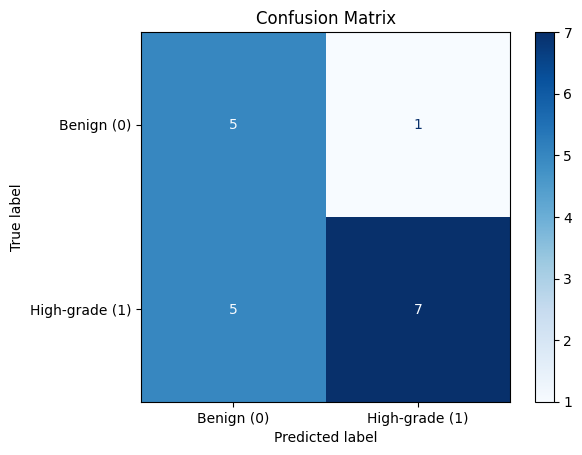

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =====================================================
# LOAD DATA
# =====================================================

pred_df = pd.read_csv(
    "/projects/e32998/STAT390_Winter2026/Team1/Code/MIL_trainer_9Dec_JointFinal/run_1/predictions.csv"
)

# Extract correct columns
y_true = pred_df["true_label"]
y_pred = pred_df["predicted_label"]

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign (0)", "High-grade (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

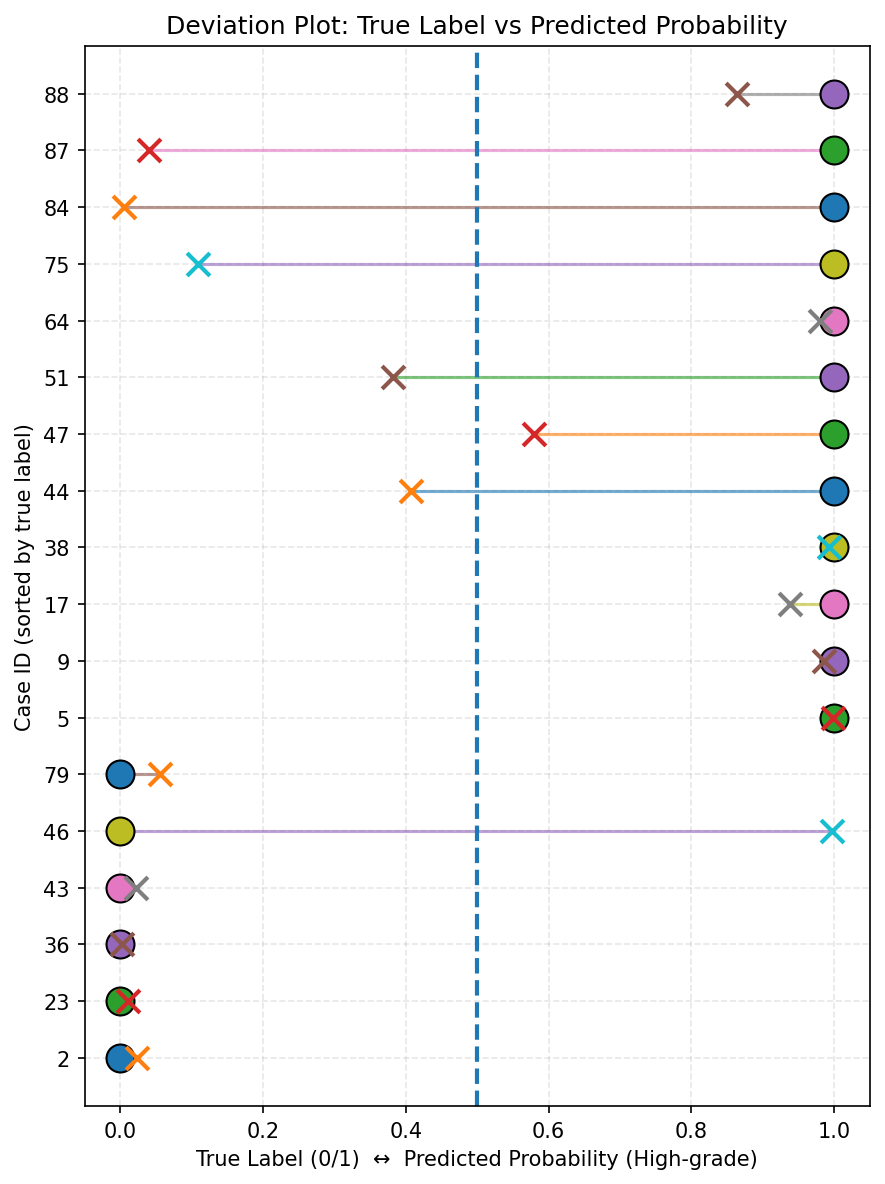

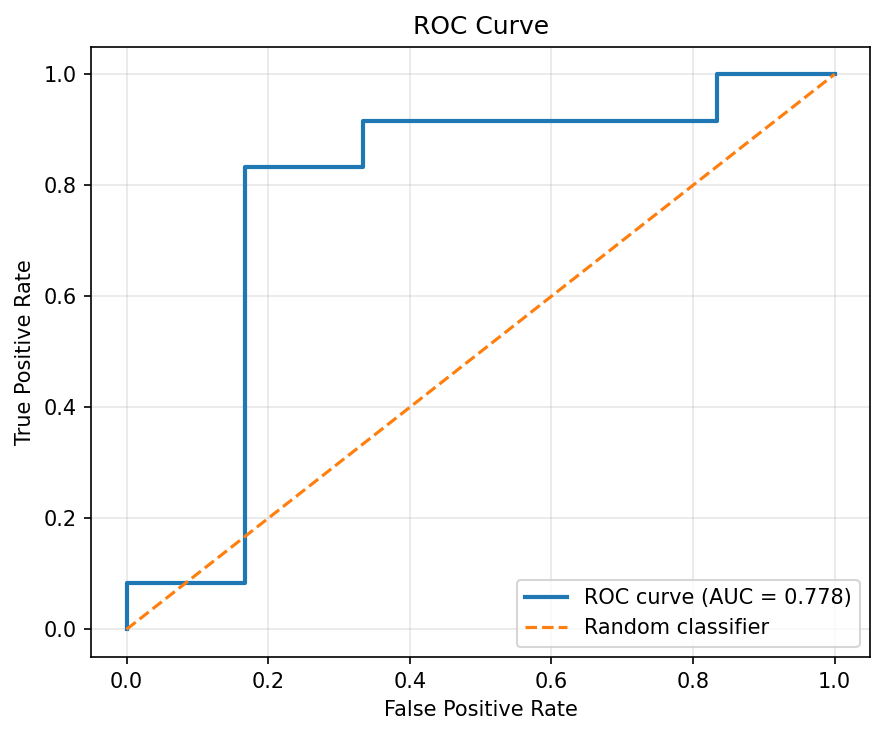


Computed AUC = 0.778


In [10]:
# =====================================================
# Combined Visualization Script
# - Deviation plot
# - AUC / ROC curve
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# -----------------------------------------------------
# Load predictions
# -----------------------------------------------------
df = pd.read_csv(
    "/projects/e32998/STAT390_Winter2026/Team1/Code/MIL_trainer_9Dec_JointFinal/run_1/predictions.csv"
)

# Sort so true=0 cases appear first (cleaner visualization)
df_sorted = df.sort_values(["true_label", "case_id"]).reset_index(drop=True)
df_sorted["case_str"] = df_sorted["case_id"].astype(str)

# -----------------------------------------------------
# 1. Deviation Plot (True vs Predicted Probability)
# -----------------------------------------------------
plt.figure(figsize=(6,8), dpi=150)

for i, row in df_sorted.iterrows():

    # Connecting line between true label and predicted probability
    plt.plot(
        [row["true_label"], row["prob_high_grade"]],
        [i, i],
        alpha=0.6,
        linewidth=1.5
    )

    # True label (large circle)
    plt.scatter(
        row["true_label"], i,
        s=180,
        marker="o",
        edgecolor="black",
        zorder=3
    )

    # Predicted probability (X marker)
    plt.scatter(
        row["prob_high_grade"], i,
        s=120,
        marker="x",
        linewidths=2,
        zorder=4
    )

plt.yticks(range(len(df_sorted)), df_sorted["case_str"])
plt.axvline(0.5, linestyle="--", linewidth=2)
plt.xlabel("True Label (0/1)  ↔  Predicted Probability (High-grade)")
plt.ylabel("Case ID (sorted by true label)")
plt.title("Deviation Plot: True Label vs Predicted Probability")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 2. AUC / ROC Curve
# -----------------------------------------------------
fpr, tpr, thresholds = roc_curve(df["true_label"], df["prob_high_grade"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5), dpi=150)
plt.plot(
    fpr, tpr,
    lw=2,
    label=f"ROC curve (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    lw=1.5,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nComputed AUC = {roc_auc:.3f}")


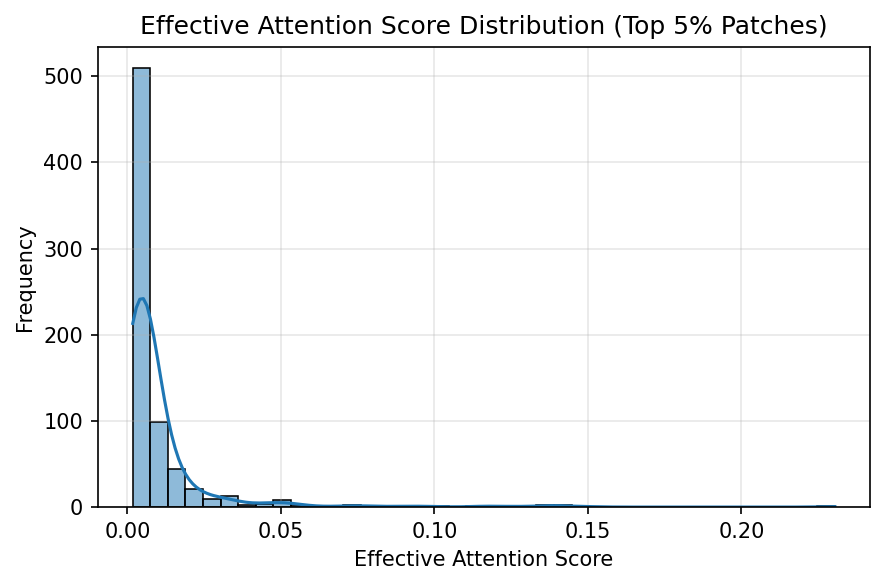

In [11]:
# =====================================================
# EFFECTIVE ATTENTION SCORE DISTRIBUTION (PATCH LEVEL)
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load top effective patches CSV
file_path = "/projects/e32998/STAT390_Winter2026/Team1/Code/MIL_trainer_9Dec_JointFinal/run_1/attention_analysis/top_effective_patches_per_case_5.0pct.csv"

df = pd.read_csv(file_path)

# Plot effective attention distribution
plt.figure(figsize=(6,4), dpi=150)
sns.histplot(df["effective_weight"], bins=40, kde=True)

plt.xlabel("Effective Attention Score")
plt.ylabel("Frequency")
plt.title("Effective Attention Score Distribution (Top 5% Patches)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


   case_id  stain  attention_weight
0       84    h&e            0.0410
1       84  melan            0.4766
2       84  sox10            0.4824
3       38    h&e            0.1196
4       38  melan            0.6930


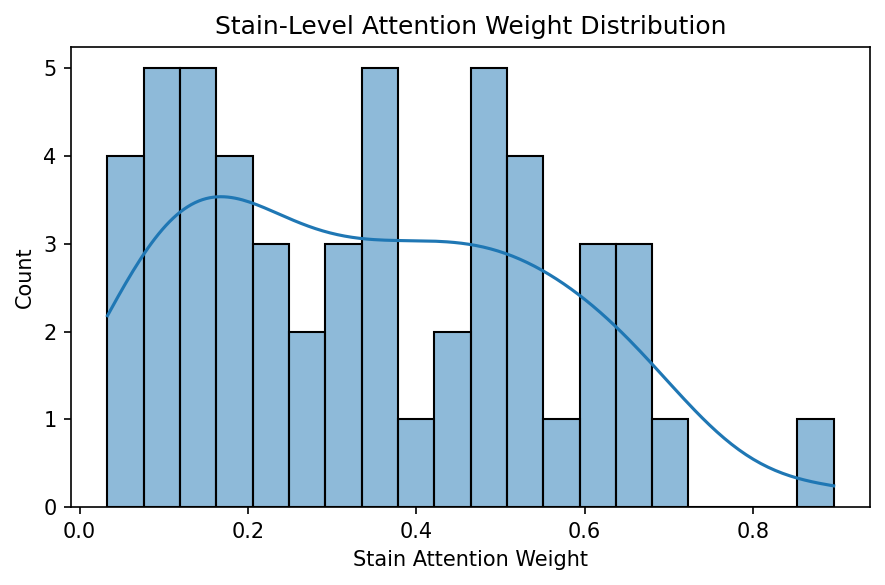

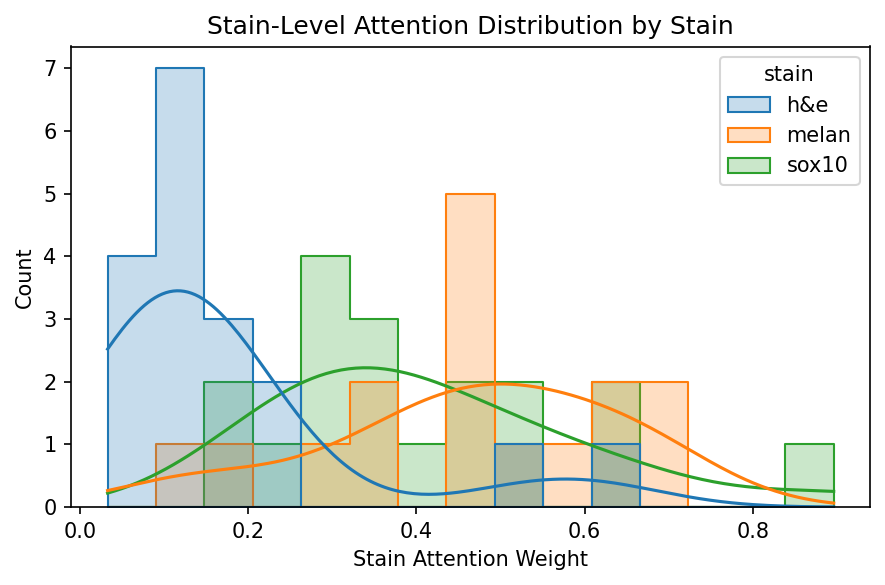

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# =====================================================
# LOAD AND PARSE ATTENTION SUMMARY (STAIN-LEVEL)
# =====================================================

file_path = "/projects/e32998/STAT390_Winter2026/Team1/Code/MIL_trainer_9Dec_JointFinal/run_1/attention_analysis/attention_summary.txt"

data = []

current_case = None
capture_stains = False

with open(file_path, "r") as f:
    for line in f:
        line = line.strip()

        # Detect case
        case_match = re.match(r"Case\s+(\d+):", line)
        if case_match:
            current_case = int(case_match.group(1))
            capture_stains = False
            continue

        # Detect stain-level attention section
        if "Stain-level attention" in line:
            capture_stains = True
            continue

        # Capture stain attention values
        if capture_stains and ":" in line:
            parts = line.split(":")
            stain_name = parts[0].strip()
            value = float(parts[1].strip())
            data.append([current_case, stain_name, value])

# Create DataFrame
attn_df = pd.DataFrame(data, columns=["case_id", "stain", "attention_weight"])

print(attn_df.head())

# =====================================================
# 1. OVERALL STAIN ATTENTION DISTRIBUTION
# =====================================================

plt.figure(figsize=(6,4), dpi=150)
sns.histplot(attn_df["attention_weight"], bins=20, kde=True)
plt.xlabel("Stain Attention Weight")
plt.title("Stain-Level Attention Weight Distribution")
plt.tight_layout()
plt.show()

# =====================================================
# 2. DISTRIBUTION BY STAIN TYPE
# =====================================================

plt.figure(figsize=(6,4), dpi=150)
sns.histplot(
    data=attn_df,
    x="attention_weight",
    hue="stain",
    bins=15,
    kde=True,
    element="step"
)
plt.xlabel("Stain Attention Weight")
plt.title("Stain-Level Attention Distribution by Stain")
plt.tight_layout()
plt.show()


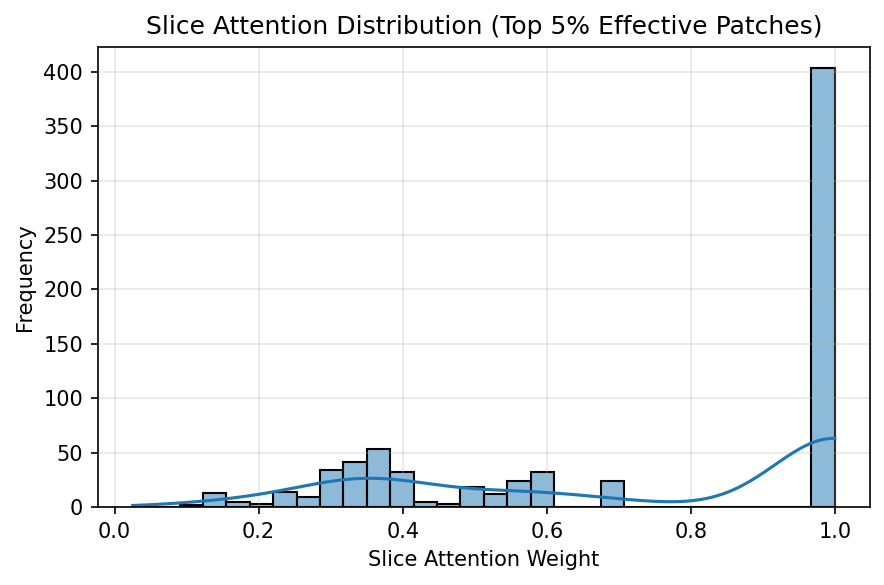

In [13]:
# =====================================================
# SLICE ATTENTION DISTRIBUTION (Top 5% Patches Only)
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/projects/e32998/STAT390_Winter2026/Team1/Code/MIL_trainer_9Dec_JointFinal/run_1/attention_analysis/top_effective_patches_per_case_5.0pct.csv"

df = pd.read_csv(file_path)

# -----------------------------------------------------
# Overall Slice Attention Distribution
# -----------------------------------------------------

plt.figure(figsize=(6,4), dpi=150)
sns.histplot(df["slice_attn_weight"], bins=30, kde=True)

plt.xlabel("Slice Attention Weight")
plt.ylabel("Frequency")
plt.title("Slice Attention Distribution (Top 5% Effective Patches)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
# =====================================================
# TOP / LOW ATTENTION PATCHES BY CLASS & CORRECTNESS
# =====================================================

import pandas as pd

file_path = "/projects/e32998/STAT390_Winter2026/Team1/Code/MIL_trainer_9Dec_JointFinal/run_1/attention_analysis/top_effective_patches_per_case_5.0pct.csv"

df = pd.read_csv(file_path)

# Define correctness
df["correct"] = df["true_label"] == df["pred_label"]

def analyze_group(condition, group_name):
    group = df[condition]
    
    print("\n================================================")
    print(group_name)
    print("================================================")
    
    if len(group) == 0:
        print("No samples in this group.")
        return
    
    # Top 10 HIGH attention
    high = group.sort_values("effective_weight", ascending=False).head(10)
    
    print("\nTop 10 HIGH attention patches:")
    print(high[[
        "case_id", "stain", "slice_idx", "patch_idx",
        "effective_weight"
    ]])
    
    # Top 10 LOW attention
    low = group.sort_values("effective_weight", ascending=True).head(10)
    
    print("\nTop 10 LOW attention patches:")
    print(low[[
        "case_id", "stain", "slice_idx", "patch_idx",
        "effective_weight"
    ]])

# -----------------------------------------------------
# 7 & 8 – Correct cases
# -----------------------------------------------------

analyze_group(
    (df["correct"]) & (df["true_label"] == 0),
    "Correct Benign"
)

analyze_group(
    (df["correct"]) & (df["true_label"] == 1),
    "Correct High-Grade"
)

# -----------------------------------------------------
# 9 & 10 – Incorrect cases
# -----------------------------------------------------

analyze_group(
    (~df["correct"]) & (df["true_label"] == 0),
    "Incorrect Benign"
)

analyze_group(
    (~df["correct"]) & (df["true_label"] == 1),
    "Incorrect High-Grade"
)



Correct Benign

Top 10 HIGH attention patches:
     case_id  stain  slice_idx  patch_idx  effective_weight
650        2  sox10          0         31          0.021484
168       23  sox10          0          4          0.020591
167       23  sox10          0         16          0.016291
166       23  sox10          0        110          0.015815
649        2  sox10          0         17          0.015636
489       36  sox10          0         30          0.015153
488       36  sox10          0         55          0.014485
648        2  melan          0         68          0.013690
647        2  sox10          0         16          0.013382
165       23  sox10          0         90          0.013071

Top 10 LOW attention patches:
     case_id  stain  slice_idx  patch_idx  effective_weight
240       79    h&e          2         36          0.001751
241       79  melan          1        102          0.001760
242       79  sox10          2         56          0.001789
243       79    h&e  